# ╔════════════════════════════════════════════════════════════╗
# ║ 🍄 きのこ　🍄
# ╚════════════════════════════════════════════════════════════╝


# ===================== IMPORTS ======================

In [159]:
# ═════════════════════ LOAD ═════════════════════
from pathlib import Path
import os

# ═════════════════════ SECTION ═════════════════════
import pandas as pd
import numpy as np

# ═════════════════════ VISUALIZATION TOOLS ═════════════════════
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

# ═════════════════════ CNN ═════════════════════
from tensorflow.keras import Sequential, layers, optimizers, callbacks, regularizers, Model
from tensorflow.keras.callbacks import EarlyStopping, CSVLogger
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.metrics import AUC
import tensorflow as tf

# ═════════════════════ OTHER ═════════════════════
from datetime import datetime
from tensorflow.keras.preprocessing.image import load_img, save_img, img_to_array

# ===================== PREPROCESSING ======================

In [45]:
# # ░░░░░░░░░░░░░░ DATA AUGMENTATION (edible) ░░░░░░░░░░░░░░

# def augment_edible(edible_dir="data/image_dataset/edible"):
#     paths = list(Path(edible_dir).rglob("*.png"))

#     for p in paths:
#         save_img(str(p.parent / f"aug_{p.name}"), np.fliplr(img_to_array(load_img(p))))

# augment_edible()

# DO NOT RUN

In [160]:
print(f"🍄 Edible: {len(list(Path('../data/image_dataset/edible').rglob('*.jpg')) + list(Path('../data/image_dataset/edible').rglob('*.png')))}")
print(f"☠️ Poisonous: {len(list(Path('../data/image_dataset/poisonous').rglob('*.jpg')) + list(Path('../data/image_dataset/poisonous').rglob('*.png')))}")

🍄 Edible: 4950
☠️ Poisonous: 5497


# =====================[■■■■■■■■■□] 90% LOADING ======================


In [161]:
paths = list(Path("../data/image_dataset/").rglob("*.png"))
df = pd.DataFrame({
    "path": paths,
    "label": [p.parent.name for p in paths]
})

# ===================== CONFIGURATION ======================

In [162]:
# ░░ 💾 Save best model ░░
timestamp = datetime.now().strftime("%d%m%Y_%H%M%S")
os.makedirs("../models/images/baseline/keras_models", exist_ok=True)
MODEL_1 = "../models/images/baseline/keras_models/model_1.keras"
MODEL_2 = "../models/images/baseline/keras_models/augmented_1.keras"
MODEL_3 = "../models/images/baseline/keras_models/augmented_2.keras"


# ░░ 🏋 Training history logs ░░
os.makedirs("../models/images/baseline/logs", exist_ok=True)
csv_logger_1 = CSVLogger(f"../models/images/baseline/logs/baseline_history_{timestamp}.csv")
csv_logger_2 = CSVLogger(f"../models/images/baseline/logs/augmented_history_{timestamp}.csv")
csv_logger_3 = CSVLogger(f"../models/images/baseline/logs/augmented_2_history_{timestamp}.csv")

# ===================== MODEL BASELINE ======================

In [163]:
def initialize_baseline_model():
    baseline = Sequential([
        layers.Input(shape=(128, 128,3)),
        layers.Rescaling(1./255),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(512, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])

    return baseline


In [164]:
baseline = initialize_baseline_model()
baseline.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_72 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_76          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_72 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_73 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_77          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_73 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_74 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_78          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_74 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_75 (Conv2D)              │ (None, 16, 16, 512)    │       590,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_79          │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_75 (MaxPooling2D) │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,881,761 (18.62 MB)

 Trainable params: 4,880,289 (18.62 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [165]:
# ░░░░░░░░░░░░░░ Compilation ░░░░░░░░░░░░░░

def compile_baseline_model(baseline):
    adam = optimizers.Adam(learning_rate = 1e-4)
    baseline.compile(
        loss = "binary_crossentropy",
        optimizer=adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )

    return baseline

In [172]:
dataset_dir = os.path.abspath("../data/image_dataset")

# ░░░░░░░░░░░░░░ Define data ░░░░░░░░░░░░░░
batch_size = 32

# We define a first one for the train data
train_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "training",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)


# We define a second one for the test data
val_ds = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size)

Found 10447 files belonging to 2 classes.
Using 8358 files for training.
Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


In [173]:
# ░░░░░░░░░░░░░░ Inspect binary classification configuration ░░░░░░░░░░░░░░
class_names = train_ds.class_names
print(class_names)

['edible', 'poisonous']


In [174]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
baseline = initialize_baseline_model()
baseline = compile_baseline_model(baseline)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_1,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=3,
                                        verbose=1,
                                        min_lr=1e-6)

history = baseline.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint, csv_logger_1],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 44s 162ms/step - accuracy: 0.5680 - auc: 0.5958 - loss: 0.7177 - precision: 0.5697 - recall: 0.7411 - val_accuracy: 0.5232 - val_auc: 0.5104 - val_loss: 0.8640 - val_precision: 0.5221 - val_recall: 0.9797 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 44s 169ms/step - accuracy: 0.6106 - auc: 0.6593 - loss: 0.6477 - precision: 0.6226 - recall: 0.6654 - val_accuracy: 0.6003 - val_auc: 0.6626 - val_loss: 0.6470 - val_precision: 0.6402 - val_recall: 0.5276 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 170ms/step - accuracy: 0.6515 - auc: 0.7134 - loss: 0.6123 - precision: 0.6689 - recall: 0.6724 - val_accuracy: 0.6467 - val_auc: 0.7124 - val_loss: 0.6130 - val_precision: 0.6596 - val_recall: 0.6621 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 44s 167ms/step - accuracy: 0.6786 - auc: 0.7531 - loss: 0.5839 - precision: 0.6943 - recall: 0.6987 - val_accuracy: 0.6515 - val_auc: 0.7

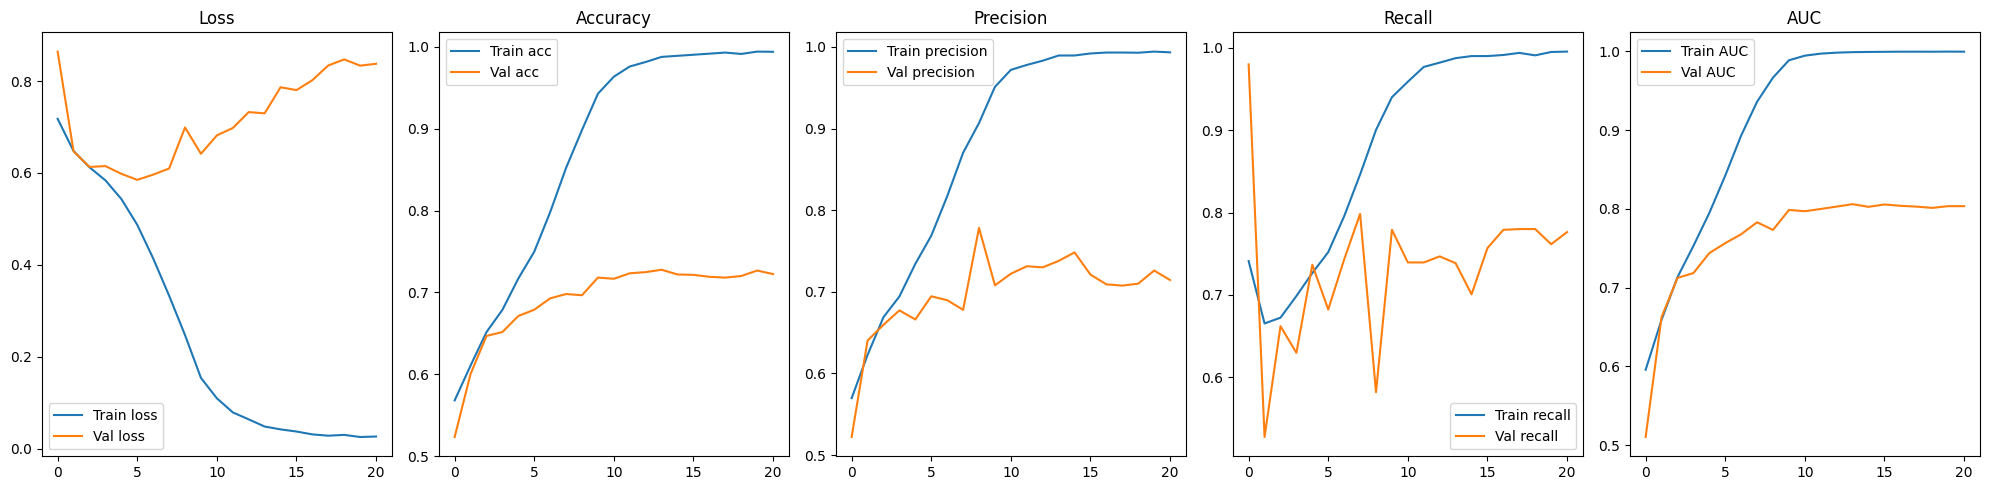

In [175]:
def plot_history(history):
    fig, ax = plt.subplots(1, 5, figsize=(20, 5))

    # ░░ Row 1 : Train & Val Loss ░░
    ax[0].set_title('Loss')
    ax[0].plot(history.epoch, history.history["loss"], label="Train loss")
    ax[0].plot(history.epoch, history.history["val_loss"], label="Val loss")

    # ░░ Row 1 : Train & Val Accuracy ░░
    ax[1].set_title('Accuracy')
    ax[1].plot(history.epoch, history.history["accuracy"], label="Train acc")
    ax[1].plot(history.epoch, history.history["val_accuracy"], label="Val acc")

    # ░░ Row 1 : Train & Val Precision ░░
    ax[2].set_title('Precision')
    ax[2].plot(history.epoch, history.history["precision"], label="Train precision")
    ax[2].plot(history.epoch, history.history["val_precision"], label="Val precision")

    # ░░ Row 1 : Train & Val Recall ░░
    ax[3].set_title('Recall')
    ax[3].plot(history.epoch, history.history["recall"], label="Train recall")
    ax[3].plot(history.epoch, history.history["val_recall"], label="Val recall")

    # ░░ Row 1 : Train & Val AUC ░░
    ax[4].set_title('AUC')
    ax[4].plot(history.epoch, history.history["auc"], label="Train AUC")
    ax[4].plot(history.epoch, history.history["val_auc"], label="Val AUC")

    for a in ax:
        a.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)

In [176]:
# Loss, Accuracy, Precision, Recall, AUC
baseline.evaluate(val_ds)

66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.6788 - auc: 0.7566 - loss: 0.5850 - precision: 0.6945 - recall: 0.6823


[0.58499675989151,
 0.6787936687469482,
 0.6944704651832581,
 0.6823204159736633,
 0.7566182613372803]

# ===================== MODEL BASELINE + DATA AUGMENTATION ======================

In [178]:
def initialize_augmented_model():
    augmented = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),
        layers.RandomZoom(0.05),

        layers.Conv2D(32, kernel_size = (4,4), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),

        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-5)),
        layers.Dropout(0.4),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented

In [179]:
augmented = initialize_augmented_model()
augmented.summary()

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_20 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_8 (RandomFlip)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_8               │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_4 (RandomZoom)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 128, 128, 32)   │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_84          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_80 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_85          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_81 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_82 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_86          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_83 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_87          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 424,033 (1.62 MB)

 Trainable params: 423,073 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [180]:
def compile_augmented_model(augmented):
    adam = optimizers.Adam(learning_rate = 1e-4)

    augmented.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented

In [181]:
%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented = initialize_augmented_model()
augmented = compile_augmented_model(augmented)

ES = EarlyStopping(
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_2,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        verbose=1,
                                        min_lr=1e-6)
history_2 = augmented.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_2],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 34s 123ms/step - accuracy: 0.5863 - auc: 0.6184 - loss: 0.7042 - precision: 0.5996 - recall: 0.6502 - val_accuracy: 0.4797 - val_auc: 0.4192 - val_loss: 0.7877 - val_precision: 0.3333 - val_recall: 9.2081e-04 - learning_rate: 1.0000e-04
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.6152 - auc: 0.6510 - loss: 0.6647 - precision: 0.6212 - recall: 0.6942 - val_accuracy: 0.5773 - val_auc: 0.6031 - val_loss: 0.6761 - val_precision: 0.5857 - val_recall: 0.6390 - learning_rate: 1.0000e-04
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 126ms/step - accuracy: 0.6255 - auc: 0.6724 - loss: 0.6468 - precision: 0.6327 - recall: 0.6921 - val_accuracy: 0.6094 - val_auc: 0.6852 - val_loss: 0.6536 - val_precision: 0.5871 - val_recall: 0.8379 - learning_rate: 1.0000e-04
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 125ms/step - accuracy: 0.6372 - auc: 0.6908 - loss: 0.6352 - precision: 0.6462 - recall: 0.6910 - val_accuracy: 0.6137 - val_auc:

# ===================== MODEL BASELINE + DATA AUGMENTATION version 2 ======================

In [182]:
def initialize_augmented_2_model():
    augmented_2 = Sequential([
        layers.Input(shape=(128,128,3)),
        layers.Rescaling(1./255),

        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.05),

        layers.Conv2D(32, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(64, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(128, kernel_size = (3,3), padding="same", strides = (1,1), activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Conv2D(256, kernel_size=(3,3), padding="same", activation='relu', kernel_regularizer=regularizers.L2(1e-4)),
        layers.BatchNormalization(),
        layers.MaxPool2D(pool_size=(2,2), padding="same"),
        layers.Dropout(0.2),

        layers.Flatten(),
        layers.Dense(256),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])
    return augmented_2

In [183]:
augmented_2 = initialize_augmented_2_model()
augmented_2.summary()

Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_22 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_10              │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_88 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_92          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_88 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_89 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_93          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_89 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_90 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_94          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_90 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_91 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_95          │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_91 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_96          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │             

 Total params: 4,586,177 (17.49 MB)

 Trainable params: 4,584,705 (17.49 MB)

 Non-trainable params: 1,472 (5.75 KB)

In [184]:
def compile_augmented_2_model(augmented_2):
    adam = optimizers.Adam(learning_rate = 1e-3)

    augmented_2.compile(
        loss = "binary_crossentropy",
        optimizer = adam,
        metrics = ["accuracy", "precision", "recall", AUC(name="auc")]
    )
    return augmented_2

In [185]:

%%time

# ░░░░░░░░░░░░░░ Training ░░░░░░░░░░░░░░
augmented_2 = initialize_augmented_2_model()
augmented_2 = compile_augmented_2_model(augmented_2)

ES = EarlyStopping(
    monitor="val_loss",   # explicit is better
    patience=15,
    restore_best_weights=True
)

# ModelCheckpoint to save the best version of our model after every epoch
checkpoint = callbacks.ModelCheckpoint(MODEL_3,
                                            monitor="val_loss",
                                            verbose=0,
                                            save_best_only=True)

# ReduceLROnPlateau to reduce the learning_rate if the model doesn't get better after a few epochs
lr_reducer = callbacks.ReduceLROnPlateau(monitor="val_loss",
                                        factor=0.5,
                                        patience=5,
                                        cooldown=2,   # <-- wait 2 epochs after reducing before monitoring again
                                        verbose=1,
                                        min_lr=1e-6)
history_3 = augmented_2.fit(
    train_ds,
    batch_size=32,
    epochs=100,
    validation_data=val_ds,
    callbacks=[ES, lr_reducer, checkpoint,csv_logger_3],
    verbose = 1
)

Epoch 1/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 35s 127ms/step - accuracy: 0.5865 - auc: 0.6211 - loss: 0.7686 - precision: 0.6036 - recall: 0.6305 - val_accuracy: 0.4701 - val_auc: 0.4505 - val_loss: 0.9212 - val_precision: 0.1111 - val_recall: 0.0028 - learning_rate: 0.0010
Epoch 2/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 33s 127ms/step - accuracy: 0.6169 - auc: 0.6663 - loss: 0.6965 - precision: 0.6299 - recall: 0.6645 - val_accuracy: 0.5668 - val_auc: 0.5982 - val_loss: 0.7612 - val_precision: 0.5591 - val_recall: 0.7882 - learning_rate: 0.0010
Epoch 3/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 45s 173ms/step - accuracy: 0.6436 - auc: 0.6981 - loss: 0.6643 - precision: 0.6553 - recall: 0.6849 - val_accuracy: 0.6151 - val_auc: 0.6825 - val_loss: 0.6734 - val_precision: 0.6062 - val_recall: 0.7413 - learning_rate: 0.0010
Epoch 4/100
262/262 ━━━━━━━━━━━━━━━━━━━━ 76s 290ms/step - accuracy: 0.6577 - auc: 0.7136 - loss: 0.6497 - precision: 0.6698 - recall: 0.6930 - val_accuracy: 0.6075 - val_auc: 0.6691 - val_lo

In [187]:
def plot_history(history, history_2, history_3):
    fig, ax = plt.subplots(6, 1, figsize=(12, 24))

    # ░░ Row 1 : Train loss ░░
    ax[0].set_title('Train Loss Comparison')
    ax[0].plot(history.epoch, history.history["loss"], label="Baseline")
    ax[0].plot(history_2.epoch, history_2.history["loss"], label="Augmented", color="red")
    ax[0].plot(history_3.epoch, history_3.history["loss"], label="Augmented_2", color="green")
    ax[0].legend()

    # ░░ Row 2 : Val loss ░░
    ax[1].set_title('Validation Loss Comparison')
    ax[1].plot(history.epoch, history.history["val_loss"], label="Baseline")
    ax[1].plot(history_2.epoch, history_2.history["val_loss"], label="Augmented", color="red")
    ax[1].plot(history_3.epoch, history_3.history["val_loss"], label="Augmented_2", color="green")
    ax[1].legend()

    # ░░ Row 3 : Train Accuracy ░░
    ax[2].set_title('Train Accuracy Comparison')
    ax[2].plot(history.epoch, history.history["accuracy"], label="Baseline")
    ax[2].plot(history_2.epoch, history_2.history["accuracy"], label="Augmented", color="red")
    ax[2].plot(history_3.epoch, history_3.history["accuracy"], label="Augmented_2", color="green")
    ax[2].legend()

    # ░░ Row 4 : Val Accuracy ░░
    ax[3].set_title('Validation Accuracy Comparison')
    ax[3].plot(history.epoch, history.history["val_accuracy"], label="Baseline")
    ax[3].plot(history_2.epoch, history_2.history["val_accuracy"], label="Augmented", color="red")
    ax[3].plot(history_3.epoch, history_3.history["val_accuracy"], label="Augmented_2", color="green")
    ax[3].legend()

    # ░░ Row 5 : Train AUC ░░
    ax[4].set_title('Train AUC Comparison')
    ax[4].plot(history.epoch, history.history["auc"], label="Baseline")
    ax[4].plot(history_2.epoch, history_2.history["auc"], label="Augmented", color="red")
    ax[4].plot(history_3.epoch, history_3.history["auc"], label="Augmented_2", color="green")
    ax[4].legend()

    # ░░ Row 6 : Val AUC ░░
    ax[5].set_title('Validation AUC Comparison')
    ax[5].plot(history.epoch, history.history["val_auc"], label="Baseline")
    ax[5].plot(history_2.epoch, history_2.history["val_auc"], label="Augmented", color="red")
    ax[5].plot(history_3.epoch, history_3.history["val_auc"], label="Augmented_2", color="green")
    ax[5].legend()

    plt.tight_layout()
    plt.show()

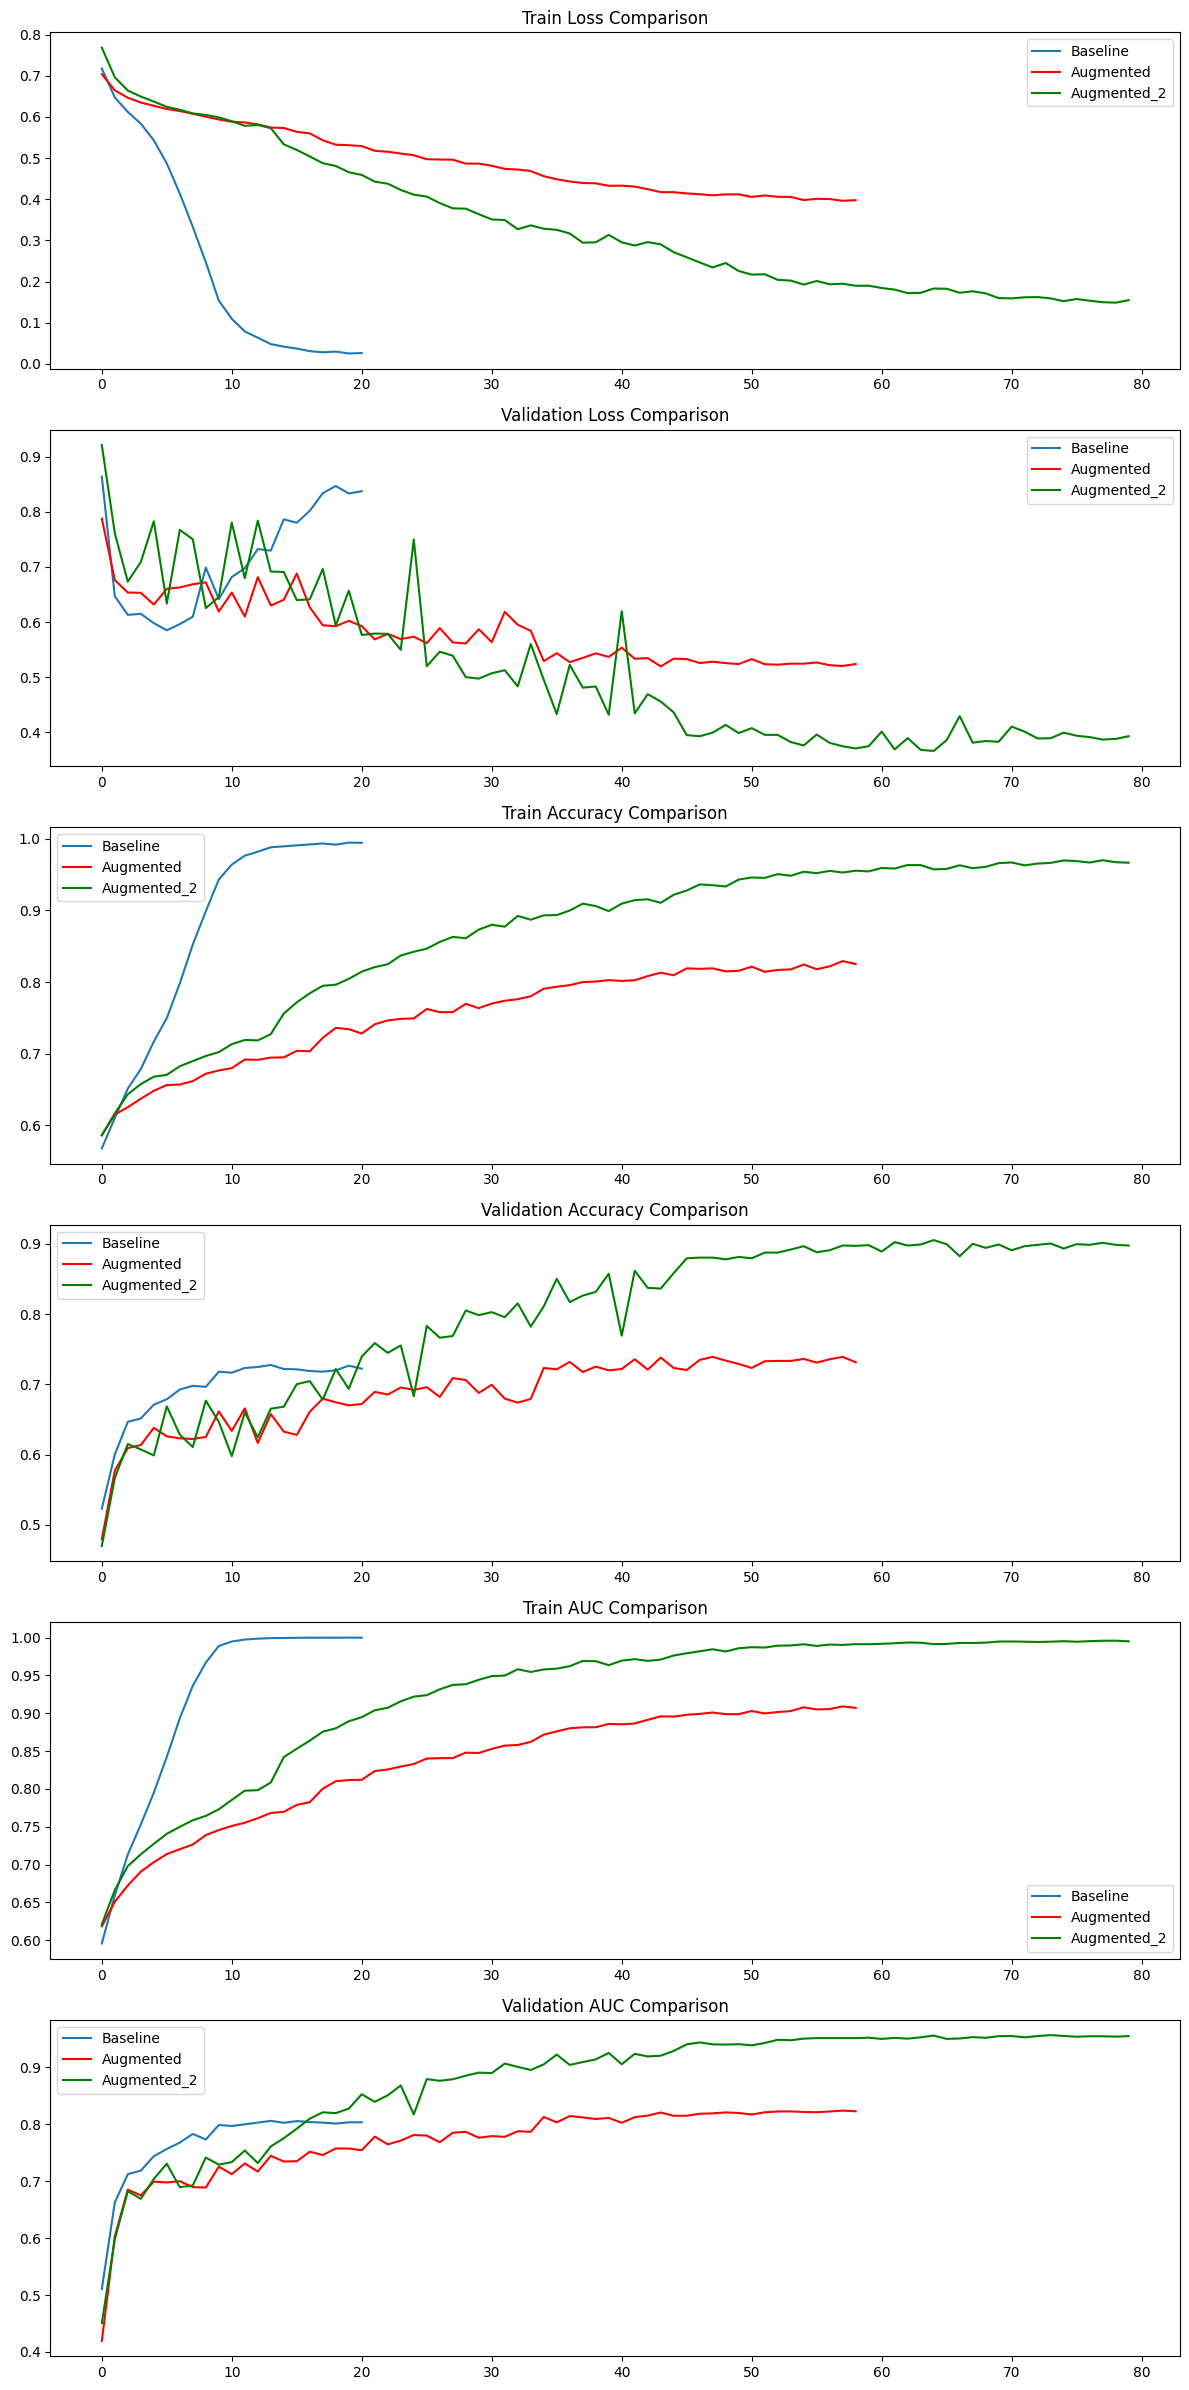

In [188]:
plot_history(history, history_2, history_3)

In [189]:
display(baseline.evaluate(val_ds), augmented.evaluate(val_ds), augmented_2.evaluate(val_ds))

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.6788 - auc: 0.7566 - loss: 0.5850 - precision: 0.6945 - recall: 0.6823
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.7382 - auc: 0.8208 - loss: 0.5194 - precision: 0.7350 - recall: 0.7762
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.9052 - auc: 0.9560 - loss: 0.3659 - precision: 0.9405 - recall: 0.8729


[0.5849968791007996,
 0.6787936687469482,
 0.6944704651832581,
 0.6823204159736633,
 0.7566182613372803]

[0.5194146037101746,
 0.7381522059440613,
 0.7349607944488525,
 0.7762430906295776,
 0.820811927318573]

[0.36592909693717957,
 0.9052178263664246,
 0.9404761791229248,
 0.8729282021522522,
 0.9560245275497437]

In [204]:
# ░░ 🔮 Prediction ░░

val_ds_predict = image_dataset_from_directory(
    dataset_dir,
    labels="inferred", # or class_names=["poisonous", "edible"]
    label_mode="binary",
    validation_split= 0.2,
    subset= "validation",
    seed=123,
    image_size=(128, 128),
    batch_size=batch_size,
    shuffle=False)

# preds_base = probability that the image belongs to class 1
preds_base = baseline.predict(val_ds_predict , verbose=0)

# preds_aug = probability that the image belongs to class 1
preds_augm = augmented.predict(val_ds_predict , verbose=0)

# preds_aug_2 = probability that the image belongs to class 1
preds_augm_2 = augmented_2.predict(val_ds_predict, verbose=0)

true_labels = np.concatenate([y for x, y in val_ds_predict ], axis=0).flatten()

df_prediction = pd.DataFrame({
    "Baseline_proba":    preds_base.flatten(),
    "Augmented_proba":   preds_augm.flatten(),
    "Augmented_2_proba": preds_augm_2.flatten(),
    "true_label":        true_labels.astype(int),
})

display(df_prediction.head(10))


Found 10447 files belonging to 2 classes.
Using 2089 files for validation.


,Baseline_proba,Augmented_proba,Augmented_2_proba,true_label
0,0.985342,0.758966,0.999439,1
1,0.796187,0.829599,0.999524,1
2,0.969895,0.453856,0.998342,1
3,0.968474,0.820750,0.999703,1
4,0.984472,0.789182,0.999560,1
5,0.673912,0.950021,0.998786,1
6,0.816859,0.867437,0.996246,1
7,0.988449,0.976412,0.999866,1
8,0.584035,0.554555,0.996820,1
9,0.588297,0.867977,0.975439,1


In [191]:
# ░░ 🔮 Prediction Label 1 ░░
# if > 0.5 → 1 else → 0

# Convert baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels = (preds_base > 0.5).astype(int)

# Convert augmented baseline predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_2 = (preds_augm > 0.5).astype(int)

# Convert augmented baseline 2 predicted probabilities into binary class labels using a 0.5 threshold.
pred_labels_3 = (preds_augm_2 > 0.5).astype(int)

display(pred_labels, pred_labels_2, pred_labels_3)

array([[1],
       [1],
       [1],
       ...,
       [1],
       [0],
       [1]], shape=(2089, 1))

array([[1],
       [1],
       [0],
       ...,
       [1],
       [0],
       [1]], shape=(2089, 1))

array([[1],
       [1],
       [1],
       ...,
       [1],
       [1],
       [1]], shape=(2089, 1))

In [ ]:
# ░░ 🎨  Let's have something prettier ░░

df_proba_results = pd.DataFrame({
    "Baseline_proba": preds_base.flatten(),
    "Augmented_proba": preds_augm.flatten(),
    "Augmented_2_proba": preds_augm_2.flatten(),
    "true_label": true_labels.flatten(),
})

class_map = dict(enumerate(class_names))

df_proba_results["Baseline_label"] = (df_proba_results["Baseline_proba"] > 0.5).astype(int)
df_proba_results["Augmented_label"] = (df_proba_results["Augmented_proba"] > 0.5).astype(int)
df_proba_results["Augmented_2_label"] = (df_proba_results["Augmented_2_proba"] > 0.5).astype(int)
df_proba_results["Baseline_class"] = (df_proba_results["Baseline_label"].map(class_map))
df_proba_results["Augmented_class"] = (df_proba_results["Augmented_label"].map(class_map))
df_proba_results["Augmented_2_class"] = (df_proba_results["Augmented_2_label"].map(class_map))

df_proba_results.to_csv(f"../models/images/baseline/results/baselines_probability_{timestamp}.csv", index=False)

df_proba_results.head(20)

# Error stats
errors = df_proba_results[df_proba_results["Augmented_2_label"] != df_proba_results["true_label"]]
print(f"Taux erreur : {len(errors)/len(df_proba_results)*100:.1f}%")
print(f"Nombre erreurs : {len(errors)}/{len(df_proba_results)}")

print("Faux négatifs (prédit edible, vrai poisonous):",
      len(df_proba_results[(df_proba_results["Augmented_2_label"]==0) & (df_proba_results["true_label"]==1)]))

Taux erreur : 3.6%
Nombre erreurs : 75/2089

Faux positifs (prédit poisonous, vrai edible): 0
Faux négatifs (prédit edible, vrai poisonous): 75


In [193]:
# ░░ 💾 Save all results ░░
os.makedirs("results", exist_ok=True)
results = []

baseline_eval = baseline.evaluate(val_ds, return_dict=True)
augmented_eval = augmented.evaluate(val_ds, return_dict=True)
augmented_2_eval = augmented_2.evaluate(val_ds, return_dict=True)

results.append({
    "model": "🧱 baseline",
    **baseline_eval
})

results.append({
    "model": "💪 augmented",
    **augmented_eval
})

results.append({
    "model": "🦾 augmented_2",
    **augmented_2_eval
})

df_results = pd.DataFrame(results)
df_results.to_csv(f"../models/images/baseline/results/df_results_eval_{timestamp}.csv", index=False)

display(df_results)

66/66 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - accuracy: 0.6788 - auc: 0.7566 - loss: 0.5850 - precision: 0.6945 - recall: 0.6823
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.7382 - auc: 0.8208 - loss: 0.5194 - precision: 0.7350 - recall: 0.7762
66/66 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9052 - auc: 0.9560 - loss: 0.3659 - precision: 0.9405 - recall: 0.8729


,model,accuracy,auc,loss,precision,recall
0,🧱 baseline,0.678794,0.756618,0.584997,0.694470,0.682320
1,💪 augmented,0.738152,0.820812,0.519415,0.734961,0.776243
2,🦾 augmented_2,0.905218,0.956025,0.365929,0.940476,0.872928
